In [1]:
import torch

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_id = "./Models/gemma-3-4b-it"

tokenizer = AutoTokenizer.from_pretrained(model_id)
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    dtype=torch.float32,
    device_map="cpu",
)


d:\terry\Documents\Repositories\Gemma.c\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0826 17:28:50.032000 29680 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0826 17:28:50.098000 29680 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
Loading weights:  20%|█▉        | 176/883 [00:06<00:28, 25.08it/s]

: 

In [2]:
from transformers import AutoProcessor
from PIL import Image

img = Image.open(r"D:\terry\Pictures\Screenshots\Screenshot 2026-07-29 180338.png")

messages = [
    {"role": "user", "content": [
        {"type": "image", "image": img},
        {"type": "text", "text": "Describe what you see"}
    ]},
]

processor = AutoProcessor.from_pretrained(model_id)
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
)


In [3]:
inputs

{'input_ids': [[2, 105, 2364, 109, 255999, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 262144, 26214

In [152]:
tokenizer.decode(256000)

'<end_of_image>'

In [128]:
tokenizer.decode(262144)

'<image_soft_token>'

In [80]:
import torch.nn.functional as F


vision_tower = model.model.vision_tower
encoder = vision_tower.encoder

patch_embedding = model.model.vision_tower.embeddings.patch_embedding
position_embedding = model.model.vision_tower.embeddings.position_embedding

model.eval()

@torch.inference_mode()
def _():
    x = inputs["pixel_values"][0]
    x = patch_embedding(x)
    x = x.view(1152, -1).mT.contiguous()
    x += position_embedding.weight
    x = x.unsqueeze(0)

    for layer in encoder.layers:
        resid = x
        x = layer.layer_norm1(x)

        # Attention
        attn = layer.self_attn
        B, T, C = x.size()
        n_heads = attn.num_heads
        head_dim = attn.head_dim

        # (B, n_heads, T, head_dim)
        xq = attn.q_proj(x).view(B, T, n_heads, head_dim).transpose(1, 2)
        xk = attn.k_proj(x).view(B, T, n_heads, head_dim).transpose(1, 2)
        xv = attn.v_proj(x).view(B, T, n_heads, head_dim).transpose(1, 2)
        att = (xq @ xk.contiguous().mT * attn.scale).softmax(-1)  # (B, n_heads, T, T)
        out = (att @ xv).transpose(1, 2).contiguous().view(B, T, C)
        x = attn.out_proj(out)
        x += resid

        resid = x
        x = layer.layer_norm2(x)

        # MLP
        mlp = layer.mlp
        x = mlp.fc1(x)
        x = F.gelu(x, approximate="tanh")
        x = mlp.fc2(x)
        x += resid
    
    x = vision_tower.post_layernorm(x)
    return x

x = _()

In [145]:
x.shape

torch.Size([1, 4096, 1152])

In [ ]:
multi_proj = model.model.multi_modal_projector

out = multi_proj.avg_pool(x.mT.contiguous().view(-1, 64, 64))
out = out.view(-1, 16*16).mT
out = out @ multi_proj.mm_input_projection_weight
out.shape

torch.Size([256, 2560])

In [4]:
model

Gemma3ForConditionalGeneration(
  (model): Gemma3Model(
    (vision_tower): SiglipVisionModel(
      (embeddings): SiglipVisionEmbeddings(
        (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
        (position_embedding): Embedding(4096, 1152)
      )
      (encoder): SiglipEncoder(
        (layers): ModuleList(
          (0-26): 27 x SiglipEncoderLayer(
            (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True, bias=True)
            (self_attn): SiglipAttention(
              (k_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
              (v_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
              (q_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
              (out_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
            )
            (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True, bias=True)
            (mlp): Sigl

In [26]:
model.config

Gemma3Config {
  "architectures": [
    "Gemma3ForConditionalGeneration"
  ],
  "boi_token_index": 255999,
  "dtype": "float32",
  "eoi_token_index": 256000,
  "eos_token_id": [
    1,
    106
  ],
  "image_token_index": 262144,
  "initializer_range": 0.02,
  "mm_tokens_per_image": 256,
  "model_type": "gemma3",
  "quantization_config": {
    "_load_in_4bit": true,
    "_load_in_8bit": false,
    "bnb_4bit_compute_dtype": "float16",
    "bnb_4bit_quant_storage": "uint8",
    "bnb_4bit_quant_type": "fp4",
    "bnb_4bit_use_double_quant": true,
    "llm_int8_enable_fp32_cpu_offload": false,
    "llm_int8_has_fp16_weight": false,
    "llm_int8_skip_modules": null,
    "llm_int8_threshold": 6.0,
    "load_in_4bit": true,
    "load_in_8bit": false,
    "quant_method": "bitsandbytes"
  },
  "text_config": {
    "_sliding_window_pattern": 6,
    "attention_bias": false,
    "attention_dropout": 0.0,
    "attn_logit_softcapping": null,
    "bos_token_id": 2,
    "dtype": "float32",
    "eos_to

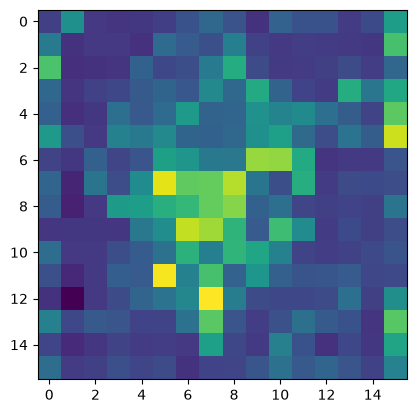

In [129]:
import matplotlib.pyplot as plt
plt.imshow(out[:, 10].detach().numpy().reshape(16, 16))

In [1]:
import json


class GemmaTokenizer:
    def __init__(self, vocab: dict[str, int], merges: list[list[str]]):
        self.vocab = vocab
        self.idx_to_str = {i: s for s, i in vocab.items()}

        self.ranks = {}
        self.merges = {}

        for i, (s1, s2) in enumerate(merges):
            pair = (vocab[s1], vocab[s2])
            self.ranks[pair] = i
            self.merges[pair] = vocab[s1 + s2]

    def encode(self, text: str) -> list[int]:
        text = text.replace(" ", "▁")

        tokens = [self.vocab["<bos>"]]
        for char in text:
            if char in self.vocab:
                tokens.append(self.vocab[char])
            else:
                for byte in char.encode("utf-8", errors="replace"):
                    tokens.append(self.vocab[f"<0x{hex(byte)[2:].upper()}>"])

        while True:
            best_rank = float("inf")
            best_pair = None

            for pair in zip(tokens[1:], tokens[2:]):
                if ((rank := self.ranks.get(pair)) is not None) and rank < best_rank:
                    best_rank = rank
                    best_pair = pair

            if best_pair is None:
                break

            i = 1
            while i < len(tokens) - 1:
                pair = (tokens[i], tokens[i + 1])
                if pair == best_pair:
                    tokens[i:i + 2] = [self.merges[pair]]
                i += 1

        return tokens

    def decode(self, tokens: list[int]) -> str:
        return (
            "".join(self.idx_to_str[tok] for tok in tokens)
        ).replace("▁", " ")


with open("./Models/gemma-3-1b-it/tokenizer.json", encoding="utf-8") as f:
    data = json.load(f)

tokenizer = GemmaTokenizer(data["model"]["vocab"], data["model"]["merges"])

In [ ]:
from export import load_bin

model, tokenizer = load_bin("exported/gemma-3-4b-it_q.bin")

In [ ]:
import torch
import torch.nn.functional as F

FP16_MAX = torch.finfo(torch.float16).max

from model import precompute_freqs_cis, apply_rotary_emb, GemmaDecoderBlock

config = model.config

freqs_cis = precompute_freqs_cis(config.head_dim, 1024, config.local_theta)

def check(name, t, i):
    if torch.isinf(t).any() or torch.isnan(t).any():
        print(f"[layer {i}] {name}: inf={torch.isinf(t).any().item()} nan={torch.isnan(t).any().item()}, max_abs={t.abs().max().item()}")


def forward(token, pos, kv_cache):
    x = torch.tensor(token)

    x = model.embedding.call(x)
    x = x * config.embed_dim**0.5

    for i, layer in enumerate(model.layers):
        assert isinstance(layer, GemmaDecoderBlock)

        resid = x
        x = layer.norm1.call(x)
        check("norm1(x)", x, i)

        attn = layer.attn
        xq = attn.q_proj.call(x).view(config.n_heads, config.head_dim)
        xk = attn.k_proj.call(x).view(config.n_kv_heads, config.head_dim)
        xv = attn.v_proj.call(x).view(config.n_kv_heads, config.head_dim)
        check("q_proj(x)", xq, i)
        check("k_proj(x)", xk, i)
        check("v_proj(x)", xv, i)

        xq = attn.q_norm.call(xq)
        xk = attn.k_norm.call(xk)
        check("q_norm", xq, i)
        check("k_norm", xk, i)

        xq = apply_rotary_emb(xq.view(1, xq.size(0), 1, xq.size(1)), freqs_cis[pos]).squeeze(0, 2)
        xk = apply_rotary_emb(xk.view(1, xk.size(0), 1, xk.size(1)), freqs_cis[pos]).squeeze(0, 2)
        check("rope(xq)", xq, i)
        check("rope(xk)", xk, i)

        kv_cache[i][pos, 0] = xk
        kv_cache[i][pos, 1] = xv

        key = kv_cache[i][:pos + 1, 0]
        val = kv_cache[i][:pos + 1, 1]

        key = key.repeat_interleave(config.n_heads // config.n_kv_heads, 1)
        val = val.repeat_interleave(config.n_heads // config.n_kv_heads, 1)

        att = ((xq.unsqueeze(-2) @ key.unsqueeze(-2).mT) * attn.scaling).squeeze(-1, -2)
        check("att(xq, key)", att, i)
        att = att[:pos + 1].T
        att = att.softmax(-1)  # (n_heads, seq_len)
        out = (att.unsqueeze(1) @ val.transpose(0, 1)).squeeze(1)
        check("val(att)", out, i)
        x = attn.o_proj.call(out.view(-1))
        check("o_proj(out)", x, i)

        x = layer.norm2.call(x)
        check("norm2(x)", x, i)
        x += resid
        x = x.clamp(-FP16_MAX, FP16_MAX)
        check("resid(x) #1", x, i)
        resid = x
        x = layer.norm3.call(x)
        check("norm3(x)", x, i)

        ffwd = layer.ffwd
        gate = ffwd.gate_proj.call(x)
        check("gate_proj(x)", gate, i)
        gate = F.gelu(gate, approximate="tanh")
        check("gelu(gate)", gate, i)
        up = ffwd.up_proj.call(x)
        check("up_proj(x)", up, i)
        fuse = gate * up
        check("gate * up", fuse, i)
        x = ffwd.down_proj.call(gate * up)
        check("down_proj(fuse)", x, i)
        x = layer.norm4.call(x)
        check("norm4(x)", x, i)
        x += resid
        x = x.clamp(-FP16_MAX, FP16_MAX)
        check("resid(x) #2", x, i)

        # print(f"Layer #{i}:")
        # print(f"  {str(x)}")

    x = model.final_norm.call(x)
    if config.quant:
        logits = x @ (model.embedding.weight.T * model.embedding.weight_scaler)
        # (B, T, vocab_size)
    else:
        logits = x @ model.embedding.weight.T

    return logits


kv_cache = [
    torch.zeros(200, 2, config.n_kv_heads, config.head_dim).to(torch.float16)
    for _ in range(config.n_layers)
]

model.eval()

def generate():
    prompt = "Once upon a time"
    print(prompt, end="")

    i = 0
    tok = 0
    for tok in tokenizer.encode(prompt):
        tok = forward(tok, i, kv_cache).argmax().item()
        i += 1

    for i in range(i, 200):
        tok = forward(tok, i, kv_cache).argmax().item()
        print(tokenizer.decode([int(tok)]), end="")


# forward(2, 0, kv_cache)

generate()


Once upon a time in a land far, far away, there lived a princess named Ella. Now, Ella

: 

In [8]:
import gc

gc.collect()

289